## Test Predictions

In [1]:
%run /Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/notebooks/02-data-preprocessing.ipynb


Training Samples: 8000
Testing Samples: 2000

Numerical Columns:
['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']

Categorical Columns:
[]


In [2]:
%run /Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/StudentPerformance/notebooks/03-model-selection.ipynb


Training Samples: 8000
Testing Samples: 2000

Numerical Columns:
['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']

Categorical Columns:
[]
MODEL: Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Parameters:
{'classifier__C': 100}
MODEL: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
MODEL: Gradient Boosting
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters:
{'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


In [3]:
y_pred = tuned_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

IndentationError: unexpected indent (3212274644.py, line 3)

In [4]:
y_pred = tuned_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

## Confusion Matrix

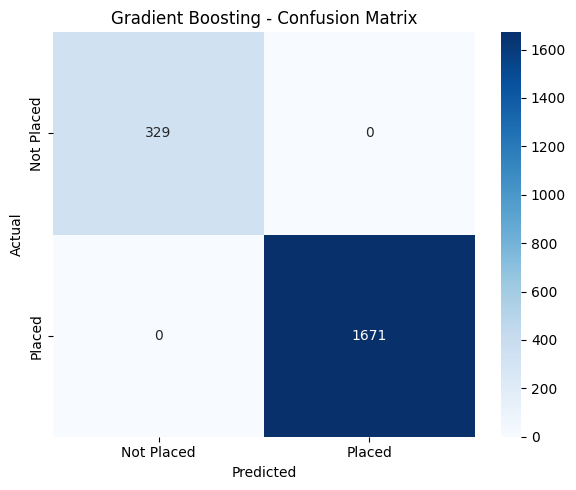

In [5]:
cm = confusion_matrix(y_test, y_pred)

labels = sorted(set(y_test))

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"{name} - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()
plt.show()

## Classification Report

In [7]:
report = classification_report(y_test, y_pred, zero_division=0)
print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       329
      Placed       1.00      1.00      1.00      1671

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Save results

In [8]:
 results.append({

        "Model": name,

        "CV Accuracy":
            round(cv_scores["test_accuracy"].mean(), 4),

        "CV Precision":
            round(cv_scores["test_precision"].mean(),4),

        "CV Recall":
            round(cv_scores["test_recall"].mean(), 4),

        "CV F1":
            round(cv_scores["test_f1"].mean(),4),

        "Test Accuracy":
            round(accuracy, 4),

        "Test Precision":
            round(precision, 4),

        "Test Recall":
            round(recall, 4),

        "Test F1":
            round(f1, 4),

        "Best Parameters":
            grid.best_params_
    })


## Track best model

In [9]:
 if f1 > best_score:
        best_score = f1
        best_model = tuned_model
        best_model_name = name

## Results comparison

In [10]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test F1",
    ascending=False
)

print("\n")
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(results_df)



FINAL MODEL COMPARISON
               Model  CV Accuracy  CV Precision  CV Recall  CV F1  \
0  Gradient Boosting          1.0           1.0        1.0    1.0   

   Test Accuracy  Test Precision  Test Recall  Test F1  \
0            1.0             1.0          1.0      1.0   

                                     Best Parameters  
0  {'classifier__learning_rate': 0.01, 'classifie...  


## Save the best pipeline

In [ ]:
joblib.dump(
    best_model,
    "best_model.pkl"
)

print("\nBest Model:", best_model_name)
print("Best F1:", round(best_score, 4))
print("Saved as: best_model.pkl")